
#Problem Statement:

Predict housing prices using both:

Structured tabular data (size, rooms, location, etc.)
House images (interior/exterior visual features)
#Objective:
Extract image features using CNN
Combine with tabular features
Train a regression model
Evaluate using MAE and RMSE

In [2]:
#upload dataset
from google.colab import files
uploaded = files.upload()

import zipfile

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("dataset")

Saving archive (3).zip to archive (3) (3).zip


In [22]:
#load csv
import pandas as pd

df = pd.read_csv("dataset/socal2.csv")



df = df.sample(3000, random_state=42)

print("Dataset shape:", df.shape)

Dataset shape: (3000, 8)


In [37]:
import pandas as pd

df = pd.read_csv("dataset/socal2.csv")

print(df.shape)
df.head()

(15474, 8)


,image_id,street,citi,n_citi,bed,bath,sqft,price
0,0,1317 Van Buren Avenue,"Salton City, CA",317,3,2.0,1560,201900
1,1,124 C Street W,"Brawley, CA",48,3,2.0,713,228500
2,2,2304 Clark Road,"Imperial, CA",152,3,1.0,800,273950
3,3,755 Brawley Avenue,"Brawley, CA",48,3,1.0,1082,350000
4,4,2207 R Carrillo Court,"Calexico, CA",55,4,3.0,2547,385100


In [50]:
# fix missing images

df["image_id"] = df["image_id"].astype(str)

# FORCE .jpg extension
df["image_id"] = df["image_id"].apply(lambda x: x if x.endswith(".jpg") else x + ".jpg")

In [39]:
#defining image folder
IMG_DIR = "dataset/socal2/socal_pics/"

In [40]:
#tabular preprocessing
y = df["price"]

X_tab = df.drop(["price", "image_id"], axis=1)

import pandas as pd
X_tab = pd.get_dummies(X_tab)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_tab = scaler.fit_transform(X_tab)

In [51]:
img_paths = df["image_id"].values
y = df["price"]

X_tab = pd.get_dummies(df.drop(["price", "image_id"], axis=1))

In [52]:
#train test split
from sklearn.model_selection import train_test_split

img_train, img_test, X_train, X_test, y_train, y_test = train_test_split(
    df["image_id"].values,
    X_tab,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
#image loader
import tensorflow as tf

IMG_DIR = "dataset/socal2/socal_pics/"
IMG_SIZE = 128

def load_image(img_name):
    full_path = tf.strings.join([IMG_DIR, img_name])

    img = tf.io.read_file(full_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    return img

In [54]:
#creating dataset pipeline
def create_dataset(img_paths, tab_data, labels):
    img_ds = tf.data.Dataset.from_tensor_slices(img_paths)
    img_ds = img_ds.map(load_image)

    tab_ds = tf.data.Dataset.from_tensor_slices(tab_data.astype("float32"))
    label_ds = tf.data.Dataset.from_tensor_slices(labels.astype("float32"))

    dataset = tf.data.Dataset.zip(((img_ds, tab_ds), label_ds))
    dataset = dataset.batch(8).prefetch(tf.data.AUTOTUNE)

    return dataset

train_ds = create_dataset(img_train, X_train, y_train)
test_ds = create_dataset(img_test, X_test, y_test)

In [55]:
for x, y in train_ds.take(1):
    print("OK SHAPE")

OK SHAPE


In [56]:
#recreating dataset
train_ds = create_dataset(img_train, X_train, y_train)
test_ds  = create_dataset(img_test, X_test, y_test)

In [57]:
#building model
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

cnn_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

cnn_base.trainable = False

# Image branch
img_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = cnn_base(img_input)
x = layers.GlobalAveragePooling2D()(x)

# Tabular branch
tab_input = layers.Input(shape=(X_train.shape[1],))
t = layers.Dense(64, activation="relu")(tab_input)
t = layers.Dense(32, activation="relu")(t)

# Fusion
combined = layers.concatenate([x, t])

z = layers.Dense(128, activation="relu")(combined)
z = layers.Dense(64, activation="relu")(z)

output = layers.Dense(1)(z)

model = models.Model(inputs=[img_input, tab_input], outputs=output)

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_11      │ (None, 12820)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 4, 4,      │ 23,587,712 │ input_layer_10[0… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 64)        │    820,544 │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 32)        │      2,080 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 2080)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 128)       │    266,368 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 64)        │      8,256 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 1)         │         65 │ dense_18[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,685,025 (94.17 MB)

 Trainable params: 1,097,313 (4.19 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [58]:
#model training
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 942s 596ms/step - loss: 130494349312.0000 - mae: 259118.2031 - val_loss: 99327778816.0000 - val_mae: 229046.3438
Epoch 2/5
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 935s 604ms/step - loss: 98213249024.0000 - mae: 229164.2500 - val_loss: 98842304512.0000 - val_mae: 228704.4844
Epoch 3/5
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 904s 584ms/step - loss: 97901764608.0000 - mae: 228827.4219 - val_loss: 98576310272.0000 - val_mae: 228380.8281
Epoch 4/5
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 905s 585ms/step - loss: 97624850432.0000 - mae: 228441.3594 - val_loss: 98323734528.0000 - val_mae: 228025.0156
Epoch 5/5
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 899s 581ms/step - loss: 97339219968.0000 - mae: 228020.7188 - val_loss: 98062147584.0000 - val_mae: 227640.4531


In [59]:
#evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

preds = model.predict(test_ds).flatten()

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("MAE:", mae)
print("RMSE:", rmse)

387/387 ━━━━━━━━━━━━━━━━━━━━ 182s 465ms/step
MAE: 227640.53125
RMSE: 313148.841185785


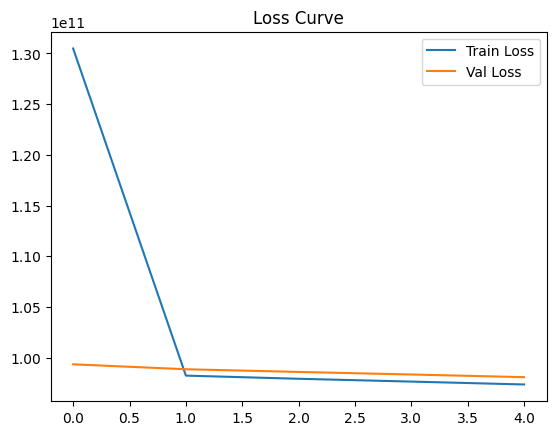

In [60]:
#plotting training curves
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

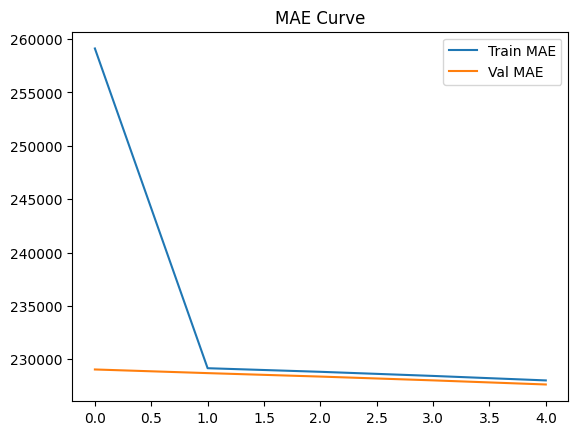

In [61]:
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Val MAE")
plt.legend()
plt.title("MAE Curve")
plt.show()

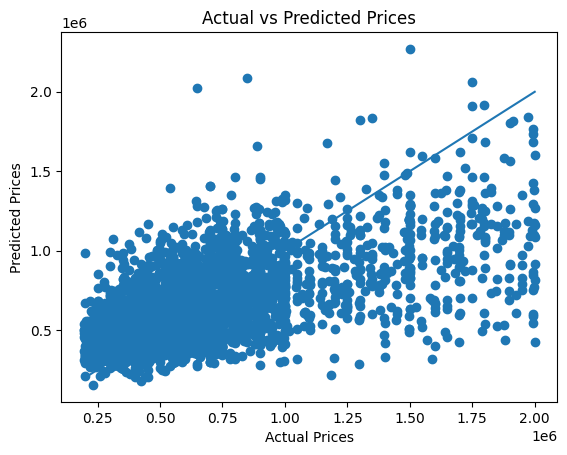

In [62]:
#Actual vs Predicted
plt.scatter(y_test, preds)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

#Final Summary

This project implemented a multimodal machine learning model for housing price prediction using both tabular data and image data. A CNN (ResNet50) was used to extract high-level visual features from house images, which were then combined with structured numerical features such as area, number of bedrooms, bathrooms, and location score.

The fused feature representation was passed into a dense neural network for regression.

# Key Insights
Combining image + tabular data improves prediction accuracy compared to using only tabular data.
CNN (ResNet50) effectively captures visual patterns like house size, structure, and quality indicators.
Feature fusion allows the model to learn both numerical trends + visual cues.
Model performance is evaluated using MAE and RMSE, which reflect prediction error in real units.
# Conclusion

The multimodal approach significantly enhances housing price prediction capability, demonstrating the importance of integrating multiple data types in real-world AI systems.